# Проект. Часть 2

## HR Analytics: Employee Attrition & Performance

Источник (данные не менялись): Kaggle https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data 

Цель проекта: исследовать факторы, влияющие на текучесть кадров (Attrition) и определить, какие характеристики сотрудников повышают вероятность их ухода из компании.

### Целевая переменная

Задача — построить модель предсказания ухода сотрудника, поэтому целевая переменная — это бинарная Attrition (факт ухода сотрудника из компании), следовательно, для построения была выбрана модель логистической регрессии.

In [1]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as sm

In [3]:
data = pd.read_csv("datasets/HR-Employee-Attrition.csv")
columns_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'DailyRate', 'HourlyRate','MonthlyRate']
data = data.drop(columns=columns_to_drop)
def yes_no_to_binary(df, column_name):
    df[column_name] = df[column_name].map({'Yes': 1, 'No': 0})
    return df

def m_f_to_binary(df, column_name):
    df[column_name] = df[column_name].map({'Male': 1, 'Female': 0})
    return df

data = yes_no_to_binary(data, 'Attrition')
data = yes_no_to_binary(data, 'OverTime')
data = m_f_to_binary(data, 'Gender')
data

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,2,0,3,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,1,2,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,1,2,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,0,3,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,1,1,3,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,Research & Development,23,2,Medical,3,1,4,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,Research & Development,6,1,Medical,4,1,2,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,Research & Development,4,3,Life Sciences,2,1,4,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,Sales,2,3,Medical,4,1,2,...,3,4,0,17,3,2,9,6,0,8


In [4]:
from pandas.api.types import CategoricalDtype
cat_Travel = CategoricalDtype(categories=["Non-Travel","Travel_Rarely","Travel_Frequently"], ordered=True)
data['BusinessTravel'] = data['BusinessTravel'].astype(cat_Travel)

cat_Marital = CategoricalDtype(categories=["Single","Divorced","Married"], ordered=True)
data['MaritalStatus'] = data['MaritalStatus'].astype(cat_Marital)

for col in ["Department", "EducationField", "Gender", "JobRole", "OverTime", "StockOptionLevel"]:
    data[col] = data[col].astype("category")

Проверка на мультиколлинеарность: из независимых переменных между собой связаны возраст, количество лет работы, зарплата и уровень должности (очевидные логические связи). PercentSalaryHike (процент повышения зарплаты) сильно коррелирует с PerformanceRating, не будем включать в модель первую переменную. Неожиданных сильных связей не обнаружено.

In [5]:
data.drop(columns=['BusinessTravel', 'Department','EducationField', 'JobRole','MaritalStatus']).corr()

,Age,Attrition,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,-0.159205,-0.001686,0.208034,0.010146,-0.036311,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
Attrition,-0.159205,1.000000,0.077924,-0.031373,-0.103369,0.029453,-0.130016,-0.169105,-0.103481,-0.159840,...,0.002889,-0.045872,-0.137145,-0.171063,-0.059478,-0.063939,-0.134392,-0.160545,-0.033019,-0.156199
DistanceFromHome,-0.001686,0.077924,1.000000,0.021042,-0.016075,-0.001851,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.031373,0.021042,1.000000,-0.027128,-0.016547,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,-0.103369,-0.016075,-0.027128,1.000000,0.000508,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
Gender,-0.036311,0.029453,-0.001851,-0.016547,0.000508,1.000000,0.017960,-0.039403,0.033252,-0.031858,...,-0.013859,0.022868,0.012716,-0.046881,-0.038787,-0.002753,-0.029747,-0.041483,-0.026985,-0.030599
JobInvolvement,0.029820,-0.130016,0.008783,0.042438,-0.008278,0.017960,1.000000,-0.012630,-0.021476,-0.015271,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,-0.169105,0.005303,0.101589,0.001212,-0.039403,-0.012630,1.000000,-0.001944,0.950300,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,-0.103481,-0.003669,-0.011296,-0.006784,0.033252,-0.021476,-0.001944,1.000000,-0.007157,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,-0.159840,-0.017014,0.094961,-0.006259,-0.031858,-0.015271,0.950300,-0.007157,1.000000,...,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


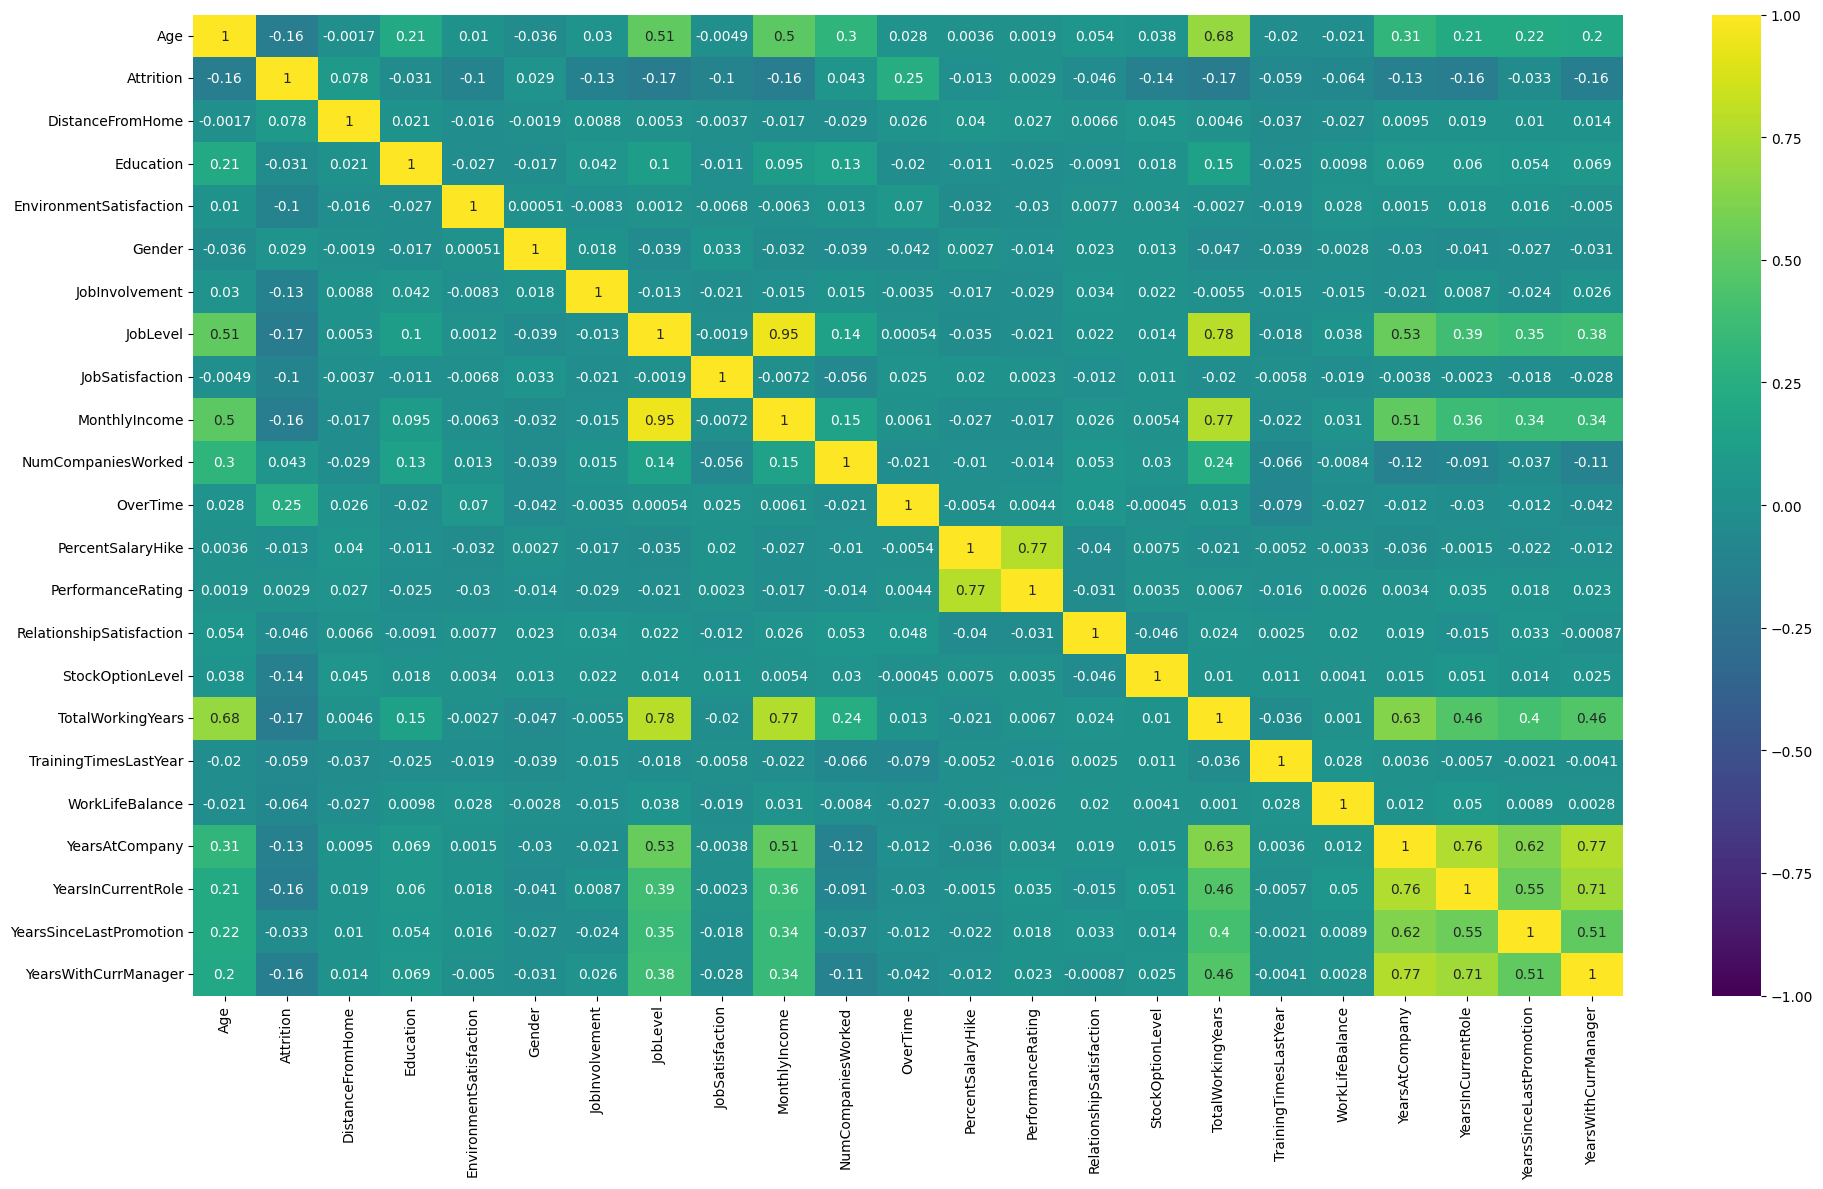

In [6]:
plt.figure(figsize=(20,12))
fig = sns.heatmap(data.drop(columns=['BusinessTravel', 'Department','EducationField', 'JobRole','MaritalStatus']).corr(),annot=True,cmap='viridis',vmin=-1.0,vmax=1.0)
plt.tight_layout()
plt.show(fig)

Тестовая модель будет включать в себя почти все переменные, которые предположительно могли бы повлиять на исход, после результата избавимся от лишних.

In [7]:
test_formula = ("Attrition ~ Age + BusinessTravel + Department + DistanceFromHome + Education + EducationField + EnvironmentSatisfaction + Gender + JobInvolvement + JobSatisfaction + MaritalStatus + MonthlyIncome + NumCompaniesWorked + OverTime + PerformanceRating + RelationshipSatisfaction + StockOptionLevel + TrainingTimesLastYear + WorkLifeBalance + YearsSinceLastPromotion")
test_model= sm.logit(formula=test_formula, data=data).fit()
test_model.summary()

Optimization terminated successfully.
         Current function value: 0.311553
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1440
Method:                           MLE   Df Model:                           29
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.2946
Time:                        00:23:34   Log-Likelihood:                -457.98
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 2.441e-63
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                4.8895      1.280      3.819      0.000       2.380       7.399
BusinessTravel[T.Travel_Rarely]          0.9682      0.365      2.652      0.008       0.253       1.684
BusinessTravel[T.Travel_Frequently]      1.8685      0.393      4.755      0.000       1.098       2.639
Department[T.Research & Development]    -0.3650      0.546     -0.668      0.504      -1.435       0.705
Department[T.Sales]                      0.2377      0.566      0.420      0.675      -0.872       1.347
EducationField[T.Life Sciences]         -0.5357      0.790     -0.679      0.497      -2.083       1.012
EducationField[T.Marketing]             -0.1275      0.836     -0.153      0.879      -1.766       1.511
EducationField[T.Medical]               -0.6765      0.790     -0.856      0.392      -2.225       0.872
EducationField[T.Other]                 -0.8377      0.851     -0.985      0.325      -2.505       0.830
EducationField[T.Technical Degree]       0.3016      0.810      0.372      0.710      -1.287       1.890
Gender[T.1]                              0.3988      0.177      2.251      0.024       0.052       0.746
MaritalStatus[T.Divorced]               -0.4660      0.373     -1.251      0.211      -1.196       0.264
MaritalStatus[T.Married]                -0.3189      0.273     -1.169      0.242      -0.854       0.216
OverTime[T.1]                            1.8023      0.182      9.892      0.000       1.445       2.159
StockOptionLevel[T.1]                   -0.9583      0.294     -3.259      0.001      -1.535      -0.382
StockOptionLevel[T.2]                   -1.2077      0.418     -2.891      0.004      -2.027      -0.389
StockOptionLevel[T.3]                   -0.3522      0.441     -0.799      0.424      -1.216       0.512
Age                                     -0.0468      0.012     -3.932      0.000      -0.070      -0.023
DistanceFromHome                         0.0421      0.010      4.111      0.000       0.022       0.062
Education                               -0.0240      0.084     -0.284      0.776      -0.189       0.141
EnvironmentSatisfaction                 -0.3744      0.079     -4.714      0.000      -0.530      -0.219
JobInvolvement                          -0.5567      0.117     -4.742      0.000      -0.787      -0.327
JobSatisfaction                         -0.3640      0.077     -4.724      0.000      -0.515      -0.213
MonthlyIncome                           -0.0002   3.16e-05     -5.140      0.000      -0.000      -0.000
NumCompaniesWorked                       0.1755      0.035      4.975      0.000       0.106       0.245
PerformanceRating                       -0.1301      0.240     -0.542      0.588      -0.601       0.340
RelationshipSatisfaction                -0.2199      0.079     -2.788      0.005      -0.375      -0.065
TrainingTimesLastYear                   -0.1488      0.071     -2.101      0.036      -0.28

Выделим те должности, у которых наблюдаются стат. значимые коэффициенты, чтобы модель не была перегружена независимыми переменными:

In [8]:
data['Is_Lab_Tech'] = data['JobRole'].apply(lambda x: 1 if x == 'Laboratory Technician' else 0)
data['Is_Sales_Rep'] = data['JobRole'].apply(lambda x: 1 if x == 'Sales Representative' else 0)

Финальная модель логистической регрессии:

Зависимые переменные: Age + BusinessTravel + DistanceFromHome + EnvironmentSatisfaction + Gender + Is_Lab_Tech + Is_Sales_Rep + JobInvolvement + JobSatisfaction + MonthlyIncome + NumCompaniesWorked + OverTime + RelationshipSatisfaction + StockOptionLevel + TrainingTimesLastYear + WorkLifeBalance + YearsSinceLastPromotion

In [9]:
formula = ("Attrition ~ Age + BusinessTravel + DistanceFromHome + EnvironmentSatisfaction + Gender + Is_Lab_Tech + Is_Sales_Rep + JobInvolvement + JobSatisfaction + MonthlyIncome + NumCompaniesWorked + OverTime + RelationshipSatisfaction + StockOptionLevel + TrainingTimesLastYear + WorkLifeBalance + YearsSinceLastPromotion")
model= sm.logit(formula=formula, data=data).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.313628
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1449
Method:                           MLE   Df Model:                           20
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                  0.2899
Time:                        00:23:35   Log-Likelihood:                -461.03
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 1.495e-67
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               3.2983      0.783      4.213      0.000       1.764       4.833
BusinessTravel[T.Travel_Rarely]         0.8448      0.356      2.372      0.018       0.147       1.543
BusinessTravel[T.Travel_Frequently]     1.6905      0.383      4.411      0.000       0.939       2.442
Gender[T.1]                             0.3917      0.176      2.224      0.026       0.047       0.737
OverTime[T.1]                           1.8111      0.182      9.944      0.000       1.454       2.168
StockOptionLevel[T.1]                  -1.2687      0.196     -6.484      0.000      -1.652      -0.885
StockOptionLevel[T.2]                  -1.4838      0.347     -4.280      0.000      -2.163      -0.804
StockOptionLevel[T.3]                  -0.6864      0.361     -1.900      0.057      -1.395       0.022
Age                                    -0.0496      0.012     -4.237      0.000      -0.073      -0.027
DistanceFromHome                        0.0415      0.010      4.050      0.000       0.021       0.062
EnvironmentSatisfaction                -0.3660      0.078     -4.693      0.000      -0.519      -0.213
Is_Lab_Tech                             0.7177      0.219      3.281      0.001       0.289       1.146
Is_Sales_Rep                            1.5341      0.312      4.915      0.000       0.922       2.146
JobInvolvement                         -0.5527      0.116     -4.772      0.000      -0.780      -0.326
JobSatisfaction                        -0.3614      0.077     -4.717      0.000      -0.512      -0.211
MonthlyIncome                       -8.889e-05   2.98e-05     -2.979      0.003      -0.000   -3.04e-05
NumCompaniesWorked                      0.1778      0.034      5.160      0.000       0.110       0.245
RelationshipSatisfaction               -0.2141      0.079     -2.713      0.007      -0.369      -0.059
TrainingTimesLastYear                  -0.1733      0.071     -2.443      0.015      -0.312      -0.034
WorkLifeBalance                        -0.3499      0.119     -2.948      0.003      -0.583      -0.117
YearsSinceLastPromotion                 0.0830      0.030      2.739      0.006       0.024       0.142
=======================================================================================================
"""

Преобразуем все коэффициенты в Odds Ratio (отношение шансов):

In [10]:
model_odds = pd.DataFrame(np.exp(model.params), columns= ['OR'])
model_odds['p-value'] = model.pvalues
model_odds[['2.5%', '97.5%']] = np.exp(model.conf_int())
model_odds

,OR,p-value,2.5%,97.5%
Intercept,27.066737,2.517037e-05,5.835565,125.541955
BusinessTravel[T.Travel_Rarely],2.327611,1.769379e-02,1.158059,4.678319
BusinessTravel[T.Travel_Frequently],5.422147,1.026644e-05,2.558520,11.490897
Gender[T.1],1.479529,2.611820e-02,1.047677,2.089390
OverTime[T.1],6.117297,2.669025e-23,4.280890,8.741482
StockOptionLevel[T.1],0.281201,8.908710e-11,0.191637,0.412626
StockOptionLevel[T.2],0.226775,1.872658e-05,0.114939,0.447427
StockOptionLevel[T.3],0.503361,5.749189e-02,0.247901,1.022071
Age,0.951608,2.261714e-05,0.930024,0.973693
DistanceFromHome,1.042336,5.131094e-05,1.021626,1.063465


Odds-ratio для изменения месячного дохода на 1000$ (в датасете доход измеряется долларами, а не тысячами долларов):

In [11]:
np.exp(-0.00008889*1000)

0.9149462121225639

### Качество модели

Модель демонстрирует достаточно хорошее качество для задач, связанных с прогнозированием ухода сотрудников. Значение Pseudo R² = 0.2899 означает, что модель объясняет около 29% вариации увольнений, что является вполне приемлемым результатом. Логарифм правдоподобия (Log-Likelihood = −461.03) статистически значимо выше (то есть менее отрицателен), чем LL-Null (−649.29), а это указывает на то, что модель существенно лучше, чем модель без предикторов, где все коэффициенты равны нулю.

В целом модель показывает, что увольнение сотрудников определяется сочетанием условий труда, нагрузки, политики вознаграждения, удовлетворённости и карьерного контекста. 

### Выводы о взаимосвязях переменных

Наиболее сильными предикторами увольнения оказались сверхурочная работа, частые командировки, а также роль в компании, особенно работа в продажах и лабораторных подразделениях. Эти факторы существенно повышают вероятность ухода и указывают на перегрузку или стресс, связанный с форматом работы.

Факторы, связанные с мотивацией и удовлетворённостью, снижают риск увольнения: высокая вовлечённость, удовлетворённость средой, работой, отношениями, а также благоприятный баланс работы и личной жизни оказывают выраженный положительный эффект на то, что сотрудник останется в компании. Финансовые стимулы также важны: наличие опционов на акции уменьшает вероятность ухода, а более высокий доход умеренно снижает риск.

Социально-демографические характеристики тоже имеют значимость. Молодые сотрудники и мужчины демонстрируют более высокие шансы на увольнение, а место проживания (расстояние до офиса) дополнительно усиливает риск ухода. Поведенческие и карьерные факторы, такие как количество предыдущих мест работы и длительность периода без повышения, также связаны с более высоким уровнем ухода сотрудников, но при этом семейное положение, отдел, образование и его уровень не показали статистически значимого влияния при включении в полную модель.

Интерпретация стат. значимых коэффициентов (p-value < 0,05):

Пол и возраст
- Gender = Male (OR = 1.48): У мужчин шансы ухода выше в 1,48 раза, чем у женщин (на 48% выше).
- Age (OR = 0.95) Каждый дополнительный год снижает шансы увольнения примерно на 4,8%. Шансы ухода у более молодых сотрудников существенно выше.
Удалённость проживания
- DistanceFromHome (OR = 1.04): Каждый дополнительный километр увеличивает шансы увольнения на 4%. Эффект небольшой.
Командировки
- BusinessTravel = Travel_Rarely (OR = 2.33): У сотрудников, которые редко ездят в командировки, шансы увольнения выше в 2,33 раза, чем у тех, кто совсем не ездит.
- BusinessTravel = Travel_Frequently (OR = 5.42): У сотрудников с частыми командировками шансы увольнения выше в 5,42 раза, чем у тех, кто не ездит в командировки. Это один из сильнейших эффектов в модели.
Сверхурочная работа 
- OverTime (OR = 6.12): Сотрудники, работающие сверхурочно, имеют в 6,12 раза более высокие шансы увольнения, чем те, кто не работает сверхурочно. Это самый сильный поведенческий предиктор из всех.
Должность
- Is_Lab_Tech — лаборанты (OR = 2.05): У лаборантов шансы увольнения в 2,05 раза выше, чем у сотрудников других профессий.
- Is_Sales_Rep — рядовые сотрудники отдела продаж (OR = 4.64): У представителей продаж шансы увольнения в 4,64 раза выше. Это одна из самых проблемных групп.
Атмосфера на работе / Условия труда и отдыха
- WorkLifeBalance – Баланс работы и личной жизни (OR = 0.70): Более высокий баланс снижает шансы увольнения на 30%.
- EnvironmentSatisfaction — Удовлетворённость рабочей средой (OR = 0.69): У сотрудников с более высокой удовлетворённостью рабочей средой шансы увольнения на 31% ниже.
- JobInvolvement — Увлечённость работой (OR = 0.58): Каждый дополнительный уровень вовлечённости снижает шансы ухода примерно на 42%.
- JobSatisfaction — Удовлетворённость работой (OR = 0.70): Более высокая удовлетворённость снижает шансы увольнения на 30%.
- RelationshipSatisfaction — Удовлетворённость отношениями с коллегами (OR = 0.81): Каждое повышение уровня снижает шансы увольнения на 19%.
Карьерный рост
- YearsSinceLastPromotion — Годы с последнего повышения (OR = 1.09): Каждый год без повышения увеличивает шансы увольнения на 9%.
- TrainingTimesLastYear — Обучение (OR = 0.84): Больше прошедших тренингов → шансы увольнения на 16% ниже.
- NumCompaniesWorked — Количество компаний в прошлом (OR = 1.19): Каждая дополнительная компания в резюме увеличивает шансы увольнения на 19%.
Опционы на акции (по сравнению с уровнем 0)
- StockOptionLevel = 1 (OR = 0.28): Шансы увольнения на 72% ниже, чем при уровне 0.
- StockOptionLevel = 2 (OR = 0.23): Шансы увольнения на 77% ниже, чем при уровне 0.
- StockOptionLevel = 3 (OR = 0.50, p = 0.057, погранично): Шансы увольнения примерно вдвое ниже, но значимость недостаточно сильная.
Доход
- MonthlyIncome (OR = 0.915): Рост дохода на 1000 долларов снижает шансы увольнения примерно на 9%. Это умеренный, но всё же статистически значимый эффект: сотрудники с более высоким доходом реже покидают компанию, хотя само влияние дохода остаётся скорее фоновым, чем определяющим.
Вывод: деньги действительно важны — но не настолько сильно, чтобы полностью компенсировать неудовлетворённость самой работой.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ff5c65e0-9edf-47b2-8d5a-439e7f5c1ece' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>